In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import textstat
import numpy as np
from scipy.spatial.distance import euclidean

import matplotlib.pyplot as plt
import pandas as pd

In [8]:
# Load sentiment analysis model and tokenizer
sentiment_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")
sentiment_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

# Load formality classification model and tokenizer
formality_tokenizer = AutoTokenizer.from_pretrained("s-nlp/mdeberta-base-formality-ranker")
formality_model = AutoModelForSequenceClassification.from_pretrained("s-nlp/mdeberta-base-formality-ranker")


In [27]:
# Define a function to calculate complexity score (readability)
def get_complexity_score(text):
    complexity_score = textstat.flesch_reading_ease(text)
    complexity_score_normalized = min(max(complexity_score / 100, 0), 1)
    return complexity_score_normalized

# Define a function to calculate formality score
def get_formality_score(text):
    inputs = formality_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = formality_model(**inputs)
    scores = outputs.logits.softmax(dim=1).detach().numpy()
    formality_score = scores[0][1]  # Higher score implies higher formality
    return formality_score

# Define a function to generate tone vector for a given text
def generate_tone_vector(text):
    complexity = get_complexity_score(text)
    formality = get_formality_score(text)
    return np.array([complexity, formality])

# Define a function to calculate tonal similarity and differences
def calculate_tonal_similarity(text_a, text_b):
    tone_vector_a = generate_tone_vector(text_a)
    tone_vector_b = generate_tone_vector(text_b)
    
    # Calculate individual differences
    complexity_diff = abs(tone_vector_a[0] - tone_vector_b[0])
    formality_diff = abs(tone_vector_a[1] - tone_vector_b[1])
    
    # Calculate the overall similarity score
    similarity_score = 1 - euclidean(tone_vector_a, tone_vector_b) / np.sqrt(2)  # Normalizing the Euclidean distance to [0,1]
    
    return complexity_diff, formality_diff, similarity_score

Complexity Difference: 0.0
Formality Difference: 0.02792757749557495
Overall Tonal Similarity Score (0 to 1): 0.9802522205707661


In [31]:
# Load Data
file_path = './iterations_1.tsv'  # Path to the .tsv file
data = pd.read_csv(file_path, sep='\t')

In [32]:
# Assuming the text is in a column named "text"; adjust if the column name is different.
line_0_text = str(data.iloc[0]["text"])  # Convert the initial reference line to a string

# Initialize lists for a, b, c values
a_values, b_values, c_values = [], [], []

# Calculate a, b, c for each line compared to line_0
for index, row in data.iterrows():
    line_n_text = str(row["text"])  # Convert each line to a string
    a, b, c = calculate_tonal_similarity(line_0_text, line_n_text)
    a_values.append(a)
    b_values.append(b)
    c_values.append(c)

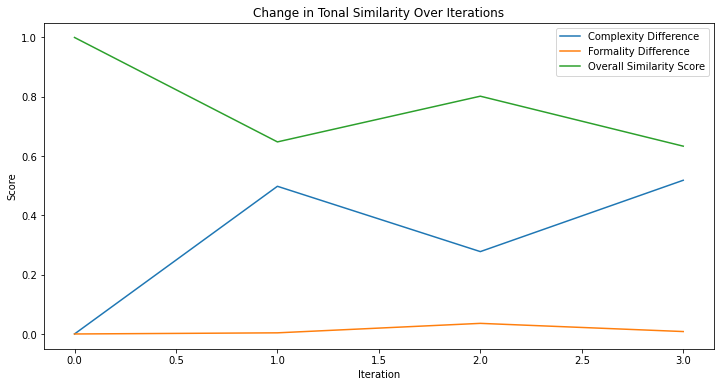

In [33]:
# Plot Results
plt.figure(figsize=(12, 6))

# Plot each variable over time
plt.plot(a_values, label="Complexity Difference")
plt.plot(b_values, label="Formality Difference")
plt.plot(c_values, label="Overall Similarity Score")

# Labeling
plt.xlabel("Iteration")
plt.ylabel("Score")
plt.title("Change in Tonal Similarity Over Iterations")
plt.legend()
plt.show()